<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# **CNN para Secuencias, Arquitectura CNN**

Instalamos lo necesario

In [ ]:
!pip install -q gensim pydot graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.2 MB/s eta 0:00:00


Importamos lo necesario

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate,
    SpatialDropout1D,
    BatchNormalization
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from gensim.downloader import load as gensim_load
from IPython.display import Image

Verificamos la GPU

In [ ]:
print("TensorFlow:", tf.__version__)
print("\nGPU:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0

GPU:
[]


Definimos parámetros

In [ ]:
vocab_size = 20000
max_len = 200
embedding_dim = 100

Cargamos el dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("\nTrain Shape:")
print(X_train.shape)

print("\nTest Shape:")
print(X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Train Shape:
(25000,)

Test Shape:
(25000,)


### **Parte A) Preprocesamiento de los datos**

Aplicamos padding a las secuencias

In [ ]:
X_train = pad_sequences(
    X_train,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("\nPadded Train Shape:")
print(X_train.shape)


Padded Train Shape:
(25000, 200)


Definimos el word index

In [ ]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Definimos el reverse word index

In [ ]:
reverse_word_index = {}

for word, idx in word_index.items():

    reverse_word_index[idx + 3] = word

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

### **Parte B) Entrenamiento de la CNN**

Cargamos GLOVE

In [ ]:
print("\nLoading GloVe...")

glove = gensim_load(
    "glove-wiki-gigaword-100"
)

print("GloVe Loaded!")


Loading GloVe...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe Loaded!


Creamos la matriz de embeddings

In [ ]:
embedding_matrix = np.random.normal(
    scale=0.6,
    size=(vocab_size, embedding_dim)
)

Llenamos la matriz de embeddings

In [ ]:
for idx in range(vocab_size):

    word = reverse_word_index.get(idx)

    if word is not None:

        if word in glove:

            embedding_matrix[idx] = glove[word]

print("\nEmbedding Matrix Shape:")
print(embedding_matrix.shape)


Embedding Matrix Shape:
(20000, 100)


Definimos la entrada de la CNN

In [ ]:
input_layer = Input(
    shape=(max_len,)
)

Definimos la capa de embedding

In [ ]:
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)(input_layer)

Definimos el Spatial Dropout 1D

In [ ]:
embedding_layer = SpatialDropout1D(0.2)(
    embedding_layer
)

print("\nEmbedding Shape:")
print(embedding_layer.shape)


Embedding Shape:
(None, 200, 100)


Definimos la rama 1

In [ ]:
conv1 = Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(embedding_layer)

conv1 = BatchNormalization()(conv1)

pool1 = GlobalMaxPooling1D()(conv1)

Definimos la rama 2

In [ ]:
conv2 = Conv1D(
    filters=64,
    kernel_size=4,
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(embedding_layer)

conv2 = BatchNormalization()(conv2)

pool2 = GlobalMaxPooling1D()(conv2)

Definimos la rama 3

In [ ]:
conv3 = Conv1D(
    filters=64,
    kernel_size=5,
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(embedding_layer)

conv3 = BatchNormalization()(conv3)

pool3 = GlobalMaxPooling1D()(conv3)

Concatenamos las salidas de las ramas

In [ ]:
concat = Concatenate()(
    [pool1, pool2, pool3]
)

print("\nConcat Shape:")
print(concat.shape)


Concat Shape:
(None, 192)


Definimos dropout

In [ ]:
dropout = Dropout(0.6)(concat)

Definimos la salida de la CNN

In [ ]:
output_layer = Dense(
    1,
    activation="sigmoid"
)(dropout)


Armamos la CNN

In [ ]:
model = Model(
    inputs=input_layer,
    outputs=output_layer
)


Compilamos la CNN

In [ ]:
model.compile(
    optimizer=Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Definimos early stopping para obtener el mejor desempeño

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

Entrenamos el modelo

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 54ms/step - accuracy: 0.5160 - loss: 2.3378 - val_accuracy: 0.6134 - val_loss: 0.6787
Epoch 2/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.5160 - loss: 1.5768 - val_accuracy: 0.6652 - val_loss: 0.6493
Epoch 3/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5303 - loss: 1.2862 - val_accuracy: 0.6928 - val_loss: 0.6424
Epoch 4/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5341 - loss: 1.1465 - val_accuracy: 0.7158 - val_loss: 0.6345
Epoch 5/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5387 - loss: 1.0239 - val_accuracy: 0.7380 - val_loss: 0.6213
Epoch 6/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5608 - loss: 0.9210 - val_accuracy: 0.7692 - val_loss: 0.5904
Epoch 7/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5918 - loss: 0.8234 - val_accuracy: 0.7704 - val_loss: 0.5553
Epoch 8/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.6198 - loss: 0.7561 - 

Evaluamos el modelo

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("FINAL TEST ACCURACY:")
print(accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8298 - loss: 0.4079
FINAL TEST ACCURACY:
0.8297600150108337


Visualizamos el plot de accuracy

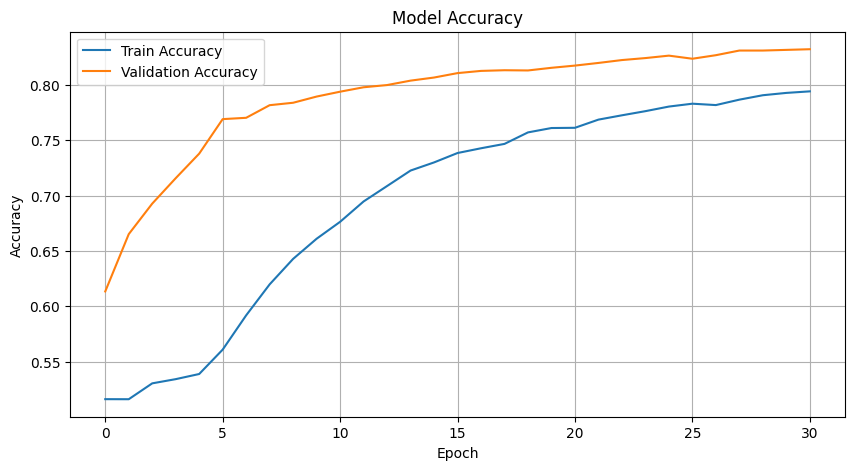

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Visualizamos el plot de loss

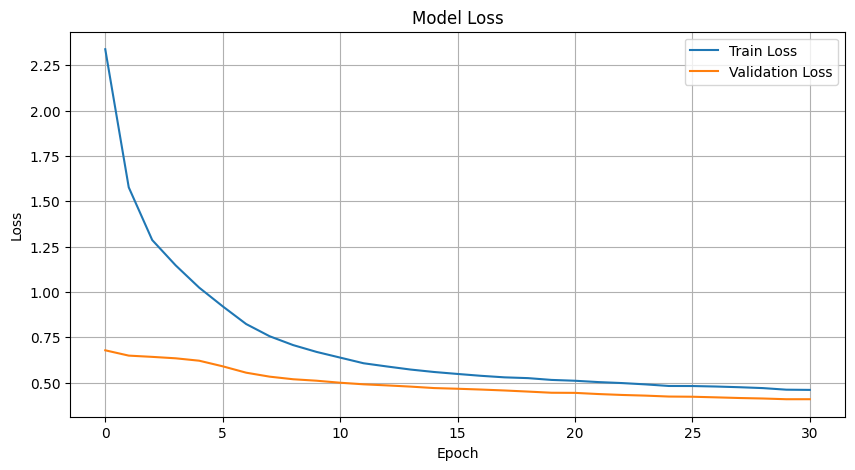

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### **Parte C) Inferencia**

Definimos función para convertir texto a secuencia

In [ ]:
def encode_text(text):

    text = text.lower()
    tokens = text.split()
    encoded = []

    for word in tokens:
        idx = word_index.get(word, 2)
        idx += 3

        if idx >= vocab_size:
            idx = 2

        encoded.append(idx)

    padded = pad_sequences(
        [encoded],
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    return padded

Definimos función para realizar la inferencia

In [ ]:
def predict_sentiment(text):

    encoded = encode_text(text)

    prediction = model.predict(
        encoded,
        verbose=0
    )[0][0]

    print("\n====================================")
    print("TEXT:")
    print(text)

    print("\nPREDICTION SCORE:")
    print(round(float(prediction), 4))

    if prediction >= 0.5:
        print("\nSENTIMIENTO: POSITIVO")
    else:
        print("\nSENTIMIENTO: NEGATIVO")

    print("====================================")

Realizamos nuevas predicciones

In [ ]:
predict_sentiment("this movie was amazing i loved it")

predict_sentiment("this film was terrible and boring")

predict_sentiment("the actors were fantastic and the story was beautiful")

predict_sentiment("worst movie ever")


TEXT:
this movie was amazing i loved it

PREDICTION SCORE:
0.8738

SENTIMIENTO: POSITIVO

TEXT:
this film was terrible and boring

PREDICTION SCORE:
0.0432

SENTIMIENTO: NEGATIVO

TEXT:
the actors were fantastic and the story was beautiful

PREDICTION SCORE:
0.8149

SENTIMIENTO: POSITIVO

TEXT:
worst movie ever

PREDICTION SCORE:
0.1099

SENTIMIENTO: NEGATIVO
